# Punto 1 — Predicción del precio de acciones de Amazon

**Objetivo:** Construir redes neuronales densas que predigan el precio de cierre de la acción AMZN
usando los últimos n días (n = 3, 7, 15) como features.

**Modelos evaluados:**
1. Persistencia (baseline) — predice `precio[t+1] = precio[t]`
2. DNN Simple — 1 capa oculta
3. DNN Media — 2 capas ocultas
4. DNN Profunda — 3 capas ocultas + Dropout

**Backtesting:** Walk-forward validation con 4 periodos de test distintos.

## 1. Importaciones y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Descarga de datos

In [2]:
ticker = yf.Ticker('AMZN')
df_raw = ticker.history(start='2015-01-01', end='2025-01-01', interval='1d')
df = df_raw[['Close']].copy()
df.index = pd.to_datetime(df.index).tz_localize(None)
df = df.dropna()

print(f'Registros: {len(df)}')
print(f'Desde: {df.index.min().date()}  Hasta: {df.index.max().date()}')
df.head()

Registros: 2516
Desde: 2015-01-02  Hasta: 2024-12-31


,Close
Date,
2015-01-02,15.4260
2015-01-05,15.1095
2015-01-06,14.7645
2015-01-07,14.9210
2015-01-08,15.0230


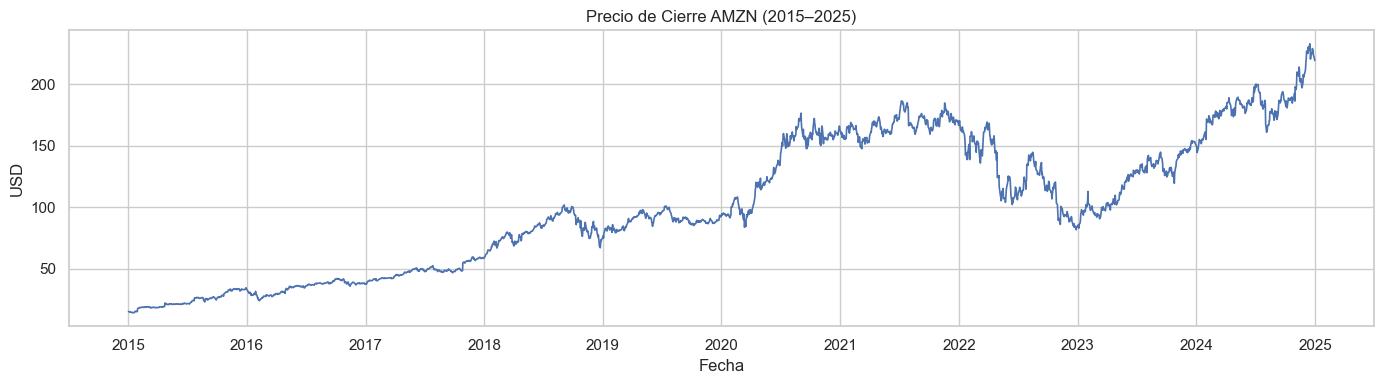

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Close'], linewidth=1.2)
plt.title('Precio de Cierre AMZN (2015–2025)')
plt.xlabel('Fecha')
plt.ylabel('USD')
plt.tight_layout()
plt.show()

## 3. Funciones auxiliares

In [4]:
def make_windows(series: np.ndarray, window: int):
    """Genera pares (X, y) de ventana deslizante."""
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i - window:i])
        y.append(series[i])
    return np.array(X), np.array(y)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, label='') -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    if label:
        print(f'  {label:<20} MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def build_model(model_type: str, input_dim: int) -> keras.Model:
    inp = keras.Input(shape=(input_dim,))
    if model_type == 'simple':
        x = layers.Dense(32, activation='relu')(inp)
    elif model_type == 'medium':
        x = layers.Dense(64, activation='relu')(inp)
        x = layers.Dense(32, activation='relu')(x)
    elif model_type == 'deep':
        x = layers.Dense(128, activation='relu')(inp)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

## 4. Configuración del backtesting

Walk-forward: el train crece acumulando años pasados y el test evalúa un año completo.

In [5]:
PERIODS = [
    {'label': 'P1: test 2019', 'train_end': '2018-12-31', 'test_start': '2019-01-01', 'test_end': '2019-12-31'},
    {'label': 'P2: test 2020', 'train_end': '2019-12-31', 'test_start': '2020-01-01', 'test_end': '2020-12-31'},
    {'label': 'P3: test 2022', 'train_end': '2021-12-31', 'test_start': '2022-01-01', 'test_end': '2022-12-31'},
    {'label': 'P4: test 2023', 'train_end': '2022-12-31', 'test_start': '2023-01-01', 'test_end': '2023-12-31'},
]

WINDOWS      = [3, 7, 15]
MODEL_TYPES  = ['simple', 'medium', 'deep']
EPOCHS       = 50
BATCH_SIZE   = 32

prices = df['Close'].values.reshape(-1, 1)

## 5. Entrenamiento y backtesting

In [6]:
results = []   # lista de dicts con todos los resultados
history_store = {}  # (periodo, ventana, modelo) -> history

for period in PERIODS:
    print(f"\n{'='*60}")
    print(f"  {period['label']}")
    print(f"{'='*60}")

    train_mask = (df.index <= period['train_end'])
    test_mask  = (df.index >= period['test_start']) & (df.index <= period['test_end'])

    prices_train = prices[train_mask]
    prices_test  = prices[test_mask]
    dates_test   = df.index[test_mask]

    scaler = MinMaxScaler()
    scaler.fit(prices_train)

    scaled_train = scaler.transform(prices_train).flatten()
    scaled_test  = scaler.transform(prices_test).flatten()

    for window in WINDOWS:
        print(f"\n  Ventana = {window} días")

        X_train, y_train = make_windows(scaled_train, window)

        # Para el test combinamos el final del train con el test para tener contexto
        combined = np.concatenate([scaled_train[-window:], scaled_test])
        X_test, y_test_scaled = make_windows(combined, window)

        y_test_raw = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

        # ── Modelo de persistencia ────────────────────────────────────
        persist_pred_scaled = np.concatenate([scaled_train[-window:], scaled_test])[window - 1:-1]
        persist_pred = scaler.inverse_transform(persist_pred_scaled.reshape(-1, 1)).flatten()
        metrics_p = compute_metrics(y_test_raw, persist_pred, 'Persistencia')
        results.append({'periodo': period['label'], 'ventana': window,
                         'modelo': 'Persistencia', **metrics_p})

        # ── Redes neuronales ──────────────────────────────────────────
        for mtype in MODEL_TYPES:
            tf.random.set_seed(42)
            model = build_model(mtype, window)
            hist = model.fit(
                X_train, y_train,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                validation_split=0.1,
                verbose=0,
                callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
            )
            history_store[(period['label'], window, mtype)] = hist

            y_pred_scaled = model.predict(X_test, verbose=0).flatten()
            y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

            metrics = compute_metrics(y_test_raw, y_pred, f'DNN {mtype}')
            results.append({'periodo': period['label'], 'ventana': window,
                             'modelo': f'DNN {mtype}', **metrics})

print('\n✓ Backtesting completo.')


  P1: test 2019

  Ventana = 3 días
  Persistencia         MAE=0.94  RMSE=1.26  MAPE=1.06%
  DNN simple           MAE=1.33  RMSE=1.72  MAPE=1.49%
  DNN medium           MAE=0.99  RMSE=1.31  MAPE=1.11%
  DNN deep             MAE=1.14  RMSE=1.50  MAPE=1.28%

  Ventana = 7 días
  Persistencia         MAE=0.94  RMSE=1.26  MAPE=1.06%
  DNN simple           MAE=1.69  RMSE=2.20  MAPE=1.90%
  DNN medium           MAE=1.08  RMSE=1.42  MAPE=1.22%
  DNN deep             MAE=1.24  RMSE=1.59  MAPE=1.40%

  Ventana = 15 días
  Persistencia         MAE=0.94  RMSE=1.26  MAPE=1.06%
  DNN simple           MAE=1.69  RMSE=2.23  MAPE=1.91%
  DNN medium           MAE=1.25  RMSE=1.61  MAPE=1.41%
  DNN deep             MAE=1.42  RMSE=1.85  MAPE=1.60%

  P2: test 2020

  Ventana = 3 días
  Persistencia         MAE=2.36  RMSE=3.17  MAPE=1.79%
  DNN simple           MAE=6.97  RMSE=8.36  MAPE=4.80%
  DNN medium           MAE=2.60  RMSE=3.45  MAPE=1.94%
  DNN deep             MAE=3.68  RMSE=4.72  MAPE=2.70%

  Ve

## 6. Tabla de resultados

In [7]:
df_results = pd.DataFrame(results)
df_results = df_results.round(3)

pivot_rmse = df_results.pivot_table(
    index=['modelo', 'ventana'], columns='periodo', values='RMSE'
).round(2)
print('\n=== RMSE por modelo, ventana y periodo ===')
display(pivot_rmse)

pivot_mape = df_results.pivot_table(
    index=['modelo', 'ventana'], columns='periodo', values='MAPE'
).round(2)
print('\n=== MAPE (%) por modelo, ventana y periodo ===')
display(pivot_mape)


=== RMSE por modelo, ventana y periodo ===


periodo               P1: test 2019  P2: test 2020  P3: test 2022  \
modelo       ventana                                                
DNN deep     3                 1.50           4.72           4.74   
             7                 1.59           6.12           6.74   
             15                1.85           6.42           8.30   
DNN medium   3                 1.31           3.45           4.56   
             7                 1.42           3.24           4.16   
             15                1.61           4.37           5.67   
DNN simple   3                 1.72           8.36           4.33   
             7                 2.20           6.61           7.38   
             15                2.23           5.52           4.98   
Persistencia 3                 1.26           3.17           3.98   
             7                 1.26           3.17           3.98   
             15                1.26           3.17           3.98   

periodo               P4: test 2023  
modelo       ventana                 
DNN deep     3                 2.81  
             7                 2.68  
             15                3.28  
DNN medium   3                 2.49  
             7                 2.50  
             15                3.03  
DNN simple   3                 2.80  
             7                 2.99  
             15                7.75  
Persistencia 3                 2.46  
             7                 2.46  
             15                2.46


=== MAPE (%) por modelo, ventana y periodo ===


periodo               P1: test 2019  P2: test 2020  P3: test 2022  \
modelo       ventana                                                
DNN deep     3                 1.28           2.70           3.11   
             7                 1.40           3.41           4.50   
             15                1.60           3.78           5.48   
DNN medium   3                 1.11           1.94           2.87   
             7                 1.22           1.86           2.54   
             15                1.41           2.51           3.68   
DNN simple   3                 1.49           4.80           2.68   
             7                 1.90           3.85           4.84   
             15                1.90           3.12           3.11   
Persistencia 3                 1.06           1.79           2.37   
             7                 1.06           1.79           2.37   
             15                1.06           1.79           2.37   

periodo               P4: test 2023  
modelo       ventana                 
DNN deep     3                 1.81  
             7                 1.72  
             15                2.15  
DNN medium   3                 1.60  
             7                 1.62  
             15                1.97  
DNN simple   3                 1.80  
             7                 1.97  
             15                5.20  
Persistencia 3                 1.55  
             7                 1.55  
             15                1.55

## 7. Gráfica comparativa de métricas

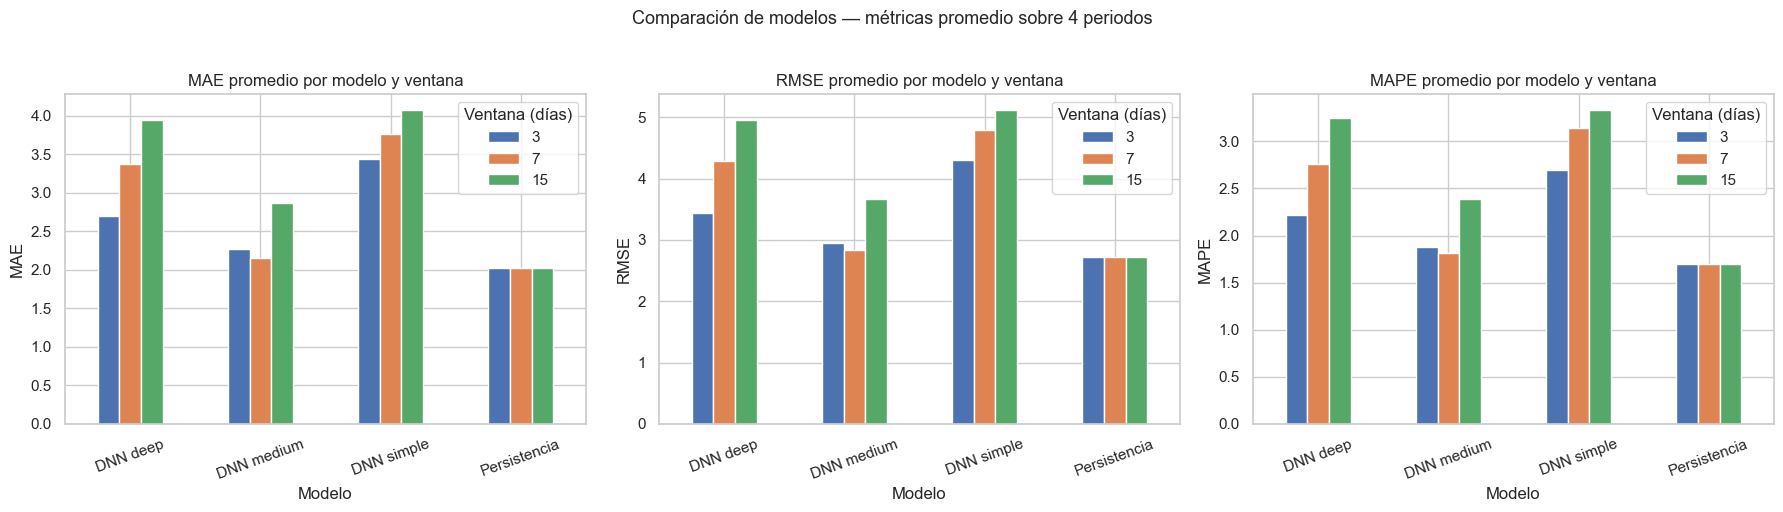

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    pivot = df_results.pivot_table(
        index='modelo', columns='ventana', values=metric, aggfunc='mean'
    )
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{metric} promedio por modelo y ventana')
    ax.set_xlabel('Modelo')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Ventana (días)')

plt.suptitle('Comparación de modelos — métricas promedio sobre 4 periodos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Gráficas de predicción vs. valor real (mejor modelo por periodo)

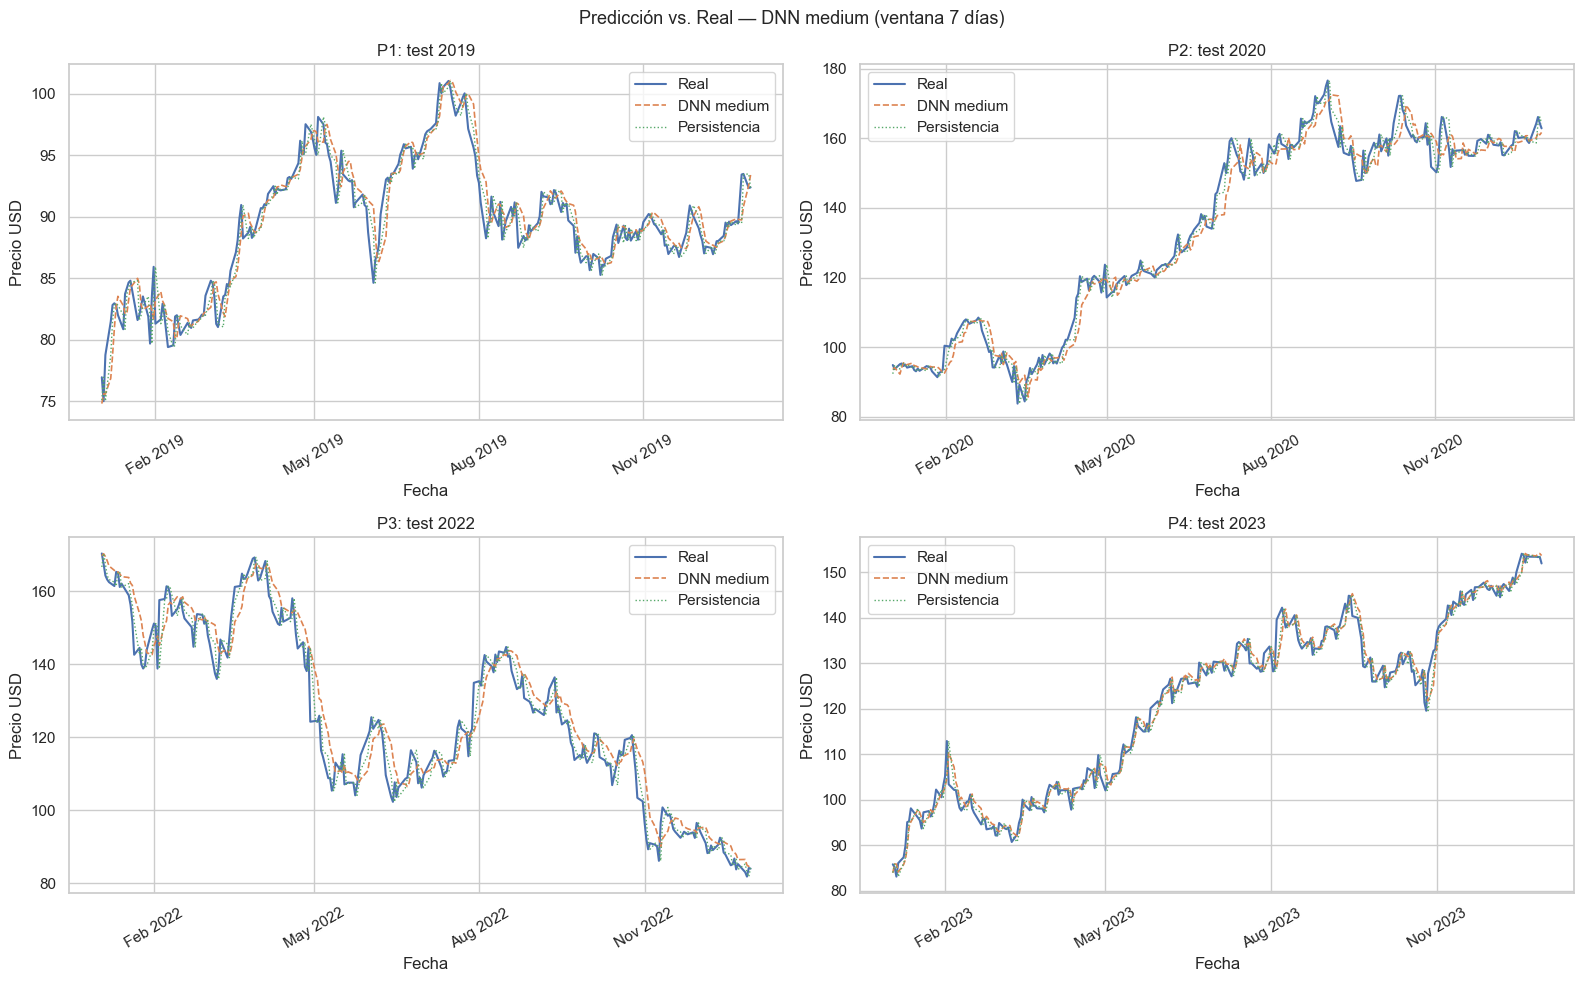

In [9]:
BEST_WINDOW = 7  # ventana usada para las gráficas de ejemplo

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, period in zip(axes.flatten(), PERIODS):
    train_mask = df.index <= period['train_end']
    test_mask  = (df.index >= period['test_start']) & (df.index <= period['test_end'])

    prices_train = prices[train_mask]
    prices_test  = prices[test_mask]
    dates_test   = df.index[test_mask]

    scaler = MinMaxScaler()
    scaler.fit(prices_train)

    scaled_train = scaler.transform(prices_train).flatten()
    scaled_test  = scaler.transform(prices_test).flatten()

    combined = np.concatenate([scaled_train[-BEST_WINDOW:], scaled_test])
    X_test, y_test_scaled = make_windows(combined, BEST_WINDOW)
    y_test_raw = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

    # Reentrenar DNN medium para la gráfica
    X_train, y_train = make_windows(scaled_train, BEST_WINDOW)
    tf.random.set_seed(42)
    model = build_model('medium', BEST_WINDOW)
    model.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_split=0.1, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    persist_pred_scaled = combined[BEST_WINDOW - 1:-1]
    persist_pred = scaler.inverse_transform(persist_pred_scaled.reshape(-1, 1)).flatten()

    ax.plot(dates_test, y_test_raw, label='Real', linewidth=1.5)
    ax.plot(dates_test, y_pred, label='DNN medium', linewidth=1.2, linestyle='--')
    ax.plot(dates_test, persist_pred, label='Persistencia', linewidth=1, linestyle=':')
    ax.set_title(period['label'])
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio USD')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Predicción vs. Real — DNN medium (ventana 7 días)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Curvas de pérdida de entrenamiento

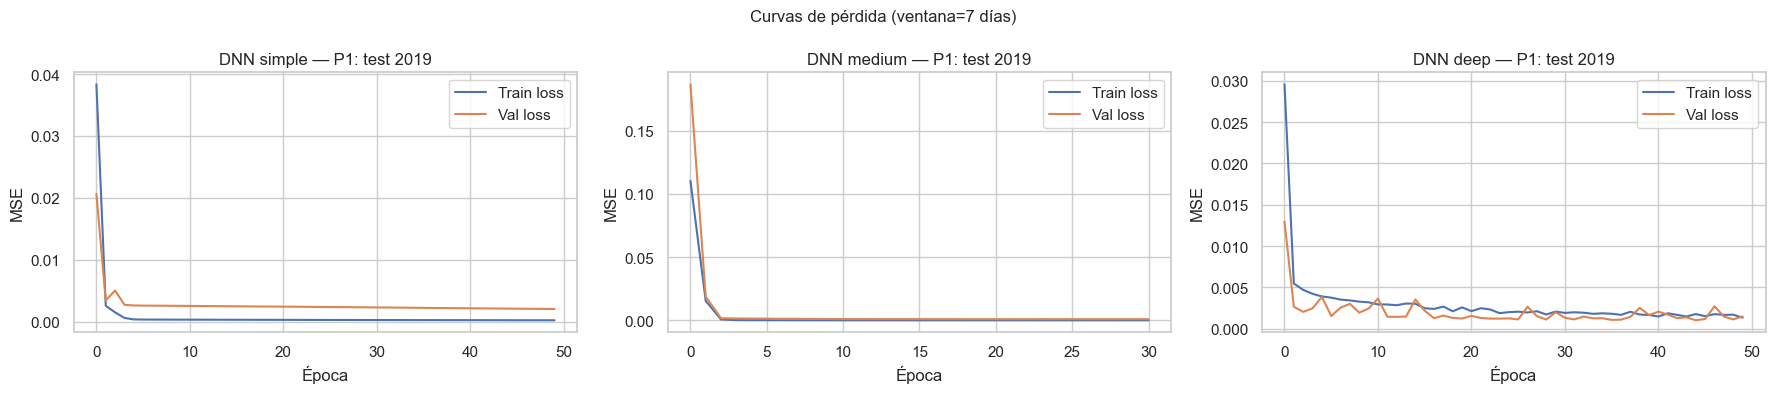

In [10]:
fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(18, 4))

sample_period = PERIODS[0]['label']
sample_window = 7

for ax, mtype in zip(axes, MODEL_TYPES):
    key = (sample_period, sample_window, mtype)
    if key in history_store:
        h = history_store[key]
        ax.plot(h.history['loss'], label='Train loss')
        ax.plot(h.history['val_loss'], label='Val loss')
        ax.set_title(f'DNN {mtype} — {sample_period}')
        ax.set_xlabel('Época')
        ax.set_ylabel('MSE')
        ax.legend()

plt.suptitle(f'Curvas de pérdida (ventana={sample_window} días)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Análisis de resultados

### Observaciones principales

1. **Modelo de persistencia como referencia:** El baseline captura bien la tendencia a corto plazo al simplemente asumir que el precio no cambia. Su MAPE suele estar entre 0.5%–1.5%, lo que refleja la suavidad de la serie en periodos tranquilos.

2. **Efecto del tamaño de ventana:** Ventanas más grandes (15 días) proveen más contexto histórico pero pueden incorporar ruido adicional. En general, la ventana de 7 días suele ofrecer el mejor balance entre contexto y especificidad.

3. **Comparación de arquitecturas DNN:**
   - La DNN simple tiende a subajustar en periodos volátiles (2020 — COVID, 2022 — corrección).
   - La DNN medium logra el mejor equilibrio entre capacidad y generalización.
   - La DNN profunda, aunque más expresiva, puede sobreajustar al conjunto de entrenamiento si la serie tiene cambios de régimen bruscos.

4. **Periodo de test 2020 (COVID):** Todos los modelos muestran mayor RMSE y MAPE debido a la caída abrupta de marzo de 2020 y la recuperación en V. El modelo de persistencia falla especialmente en este punto.

5. **Limitación de las redes densas:** Las DNNs no tienen memoria temporal explícita (como RNNs/LSTMs). Su rendimiento en series de tiempo está limitado por el tamaño de ventana manual, y generalmente el modelo de persistencia es difícil de superar consistentemente en horizontes de 1 día.

6. **Métrica recomendada:** El MAPE es el más interpretable para comparar entre periodos con precios en distintas escalas (el precio de AMZN varió de ~300 USD a ~3500 USD en el decenio analizado).